# L2: External Integration: Project Progress Report

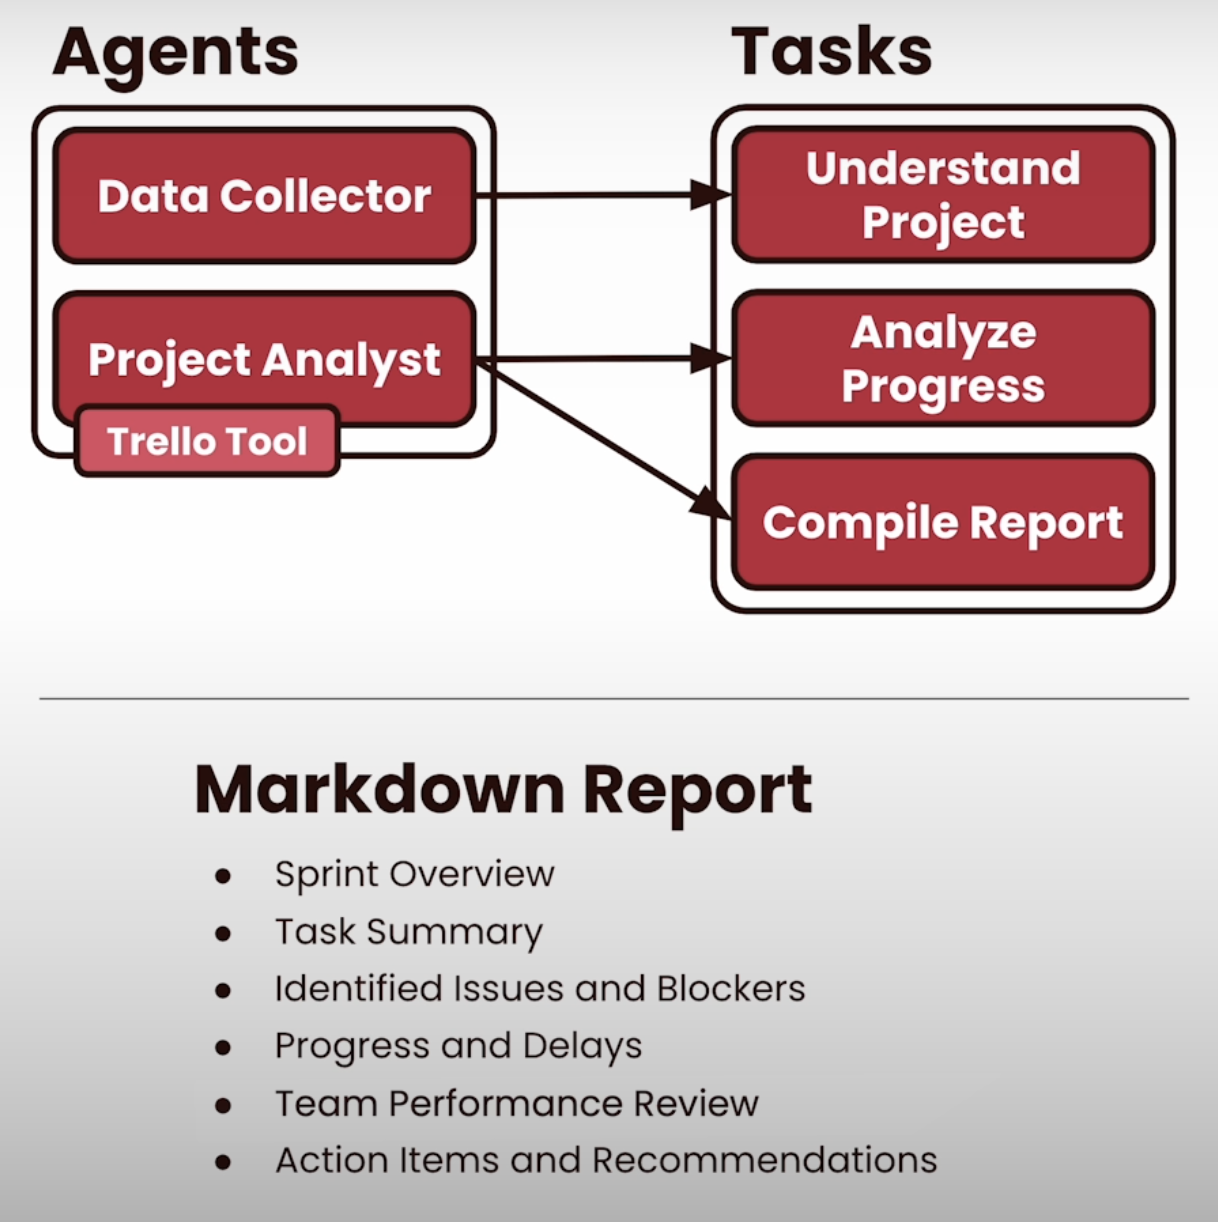

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

## Initial Imports

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
from helper import load_env
load_env()

import os
import json
import yaml
from crewai import Agent, Task, Crew

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

## Load OpenAI Model

In [2]:
os.environ['OPENAI_MODEL_NAME'] = 'gpt-4o-mini'

## Loading Tasks and Agents YAML files

In [3]:
# Define file paths for YAML configurations
files = {
    'agents': 'config/agents.yaml',
    'tasks': 'config/tasks.yaml'
}

# Load configurations from YAML files
configs = {}
for config_type, file_path in files.items():
    with open(file_path, 'r') as file:
        configs[config_type] = yaml.safe_load(file)

# Assign loaded configurations to specific variables
agents_config = configs['agents']
tasks_config = configs['tasks']

## Creating Custom Tools

In [4]:
from crewai_tools import BaseTool
import requests

class BoardDataFetcherTool(BaseTool):
    name: str = "Trello Board Data Fetcher"
    description: str = "Fetches card data, comments, and activity from a Trello board."

    api_key: str = os.environ['TRELLO_API_KEY']
    api_token: str = os.environ['TRELLO_API_TOKEN']
    board_id: str = os.environ['TRELLO_BOARD_ID']

    def _run(self) -> dict:
        """
        Fetch all cards from the specified Trello board.
        """
        url = f"{os.getenv('DLAI_TRELLO_BASE_URL', 'https://api.trello.com')}/1/boards/{self.board_id}/cards"

        query = {
            'key': self.api_key,
            'token': self.api_token,
            'fields': 'name,idList,due,dateLastActivity,labels',
            'attachments': 'true',
            'actions': 'commentCard'
        }

        response = requests.get(url, params=query)

        if response.status_code == 200:
            return response.json()
        else:
            # Fallback in case of timeouts or other issues
            return json.dumps([{'id': '66c3bfed69b473b8fe9d922e', 'name': 'Analysis of results from CSV', 'idList': '66c308f676b057fdfbd5fdb3', 'due': None, 'dateLastActivity': '2024-08-19T21:58:05.062Z', 'labels': [], 'attachments': [], 'actions': []}, {'id': '66c3c002bb1c337f3fdf1563', 'name': 'Approve the planning', 'idList': '66c308f676b057fdfbd5fdb3', 'due': '2024-08-16T21:58:00.000Z', 'dateLastActivity': '2024-08-19T21:58:57.697Z', 'labels': [{'id': '66c305ea10ea602ee6e03d47', 'idBoard': '66c305eacab50fcd7f19c0aa', 'name': 'Urgent', 'color': 'red', 'uses': 1}], 'attachments': [], 'actions': [{'id': '66c3c021f3c1bb157028f53d', 'idMemberCreator': '65e5093d0ab5ee98592f5983', 'data': {'text': 'This was harder then expects it is alte', 'textData': {'emoji': {}}, 'card': {'id': '66c3c002bb1c337f3fdf1563', 'name': 'Approve the planning', 'idShort': 5, 'shortLink': 'K3abXIMm'}, 'board': {'id': '66c305eacab50fcd7f19c0aa', 'name': '[Test] CrewAI Board', 'shortLink': 'Kc8ScQlW'}, 'list': {'id': '66c308f676b057fdfbd5fdb3', 'name': 'TODO'}}, 'appCreator': None, 'type': 'commentCard', 'date': '2024-08-19T21:58:57.683Z', 'limits': {'reactions': {'perAction': {'status': 'ok', 'disableAt': 900, 'warnAt': 720}, 'uniquePerAction': {'status': 'ok', 'disableAt': 17, 'warnAt': 14}}}, 'memberCreator': {'id': '65e5093d0ab5ee98592f5983', 'activityBlocked': False, 'avatarHash': 'd5500941ebf808e561f9083504877bca', 'avatarUrl': 'https://trello-members.s3.amazonaws.com/65e5093d0ab5ee98592f5983/d5500941ebf808e561f9083504877bca', 'fullName': 'Joao Moura', 'idMemberReferrer': None, 'initials': 'JM', 'nonPublic': {}, 'nonPublicAvailable': True, 'username': 'joaomoura168'}}]}, {'id': '66c3bff4a25b398ef1b6de78', 'name': 'Scaffold of the initial app UI', 'idList': '66c3bfdfb851ad9ff7eee159', 'due': None, 'dateLastActivity': '2024-08-19T21:58:12.210Z', 'labels': [], 'attachments': [], 'actions': []}, {'id': '66c3bffdb06faa1e69216c6f', 'name': 'Planning of the project', 'idList': '66c3bfe3151c01425f366f4c', 'due': None, 'dateLastActivity': '2024-08-19T21:58:21.081Z', 'labels': [], 'attachments': [], 'actions': []}])


class CardDataFetcherTool(BaseTool):
  name: str = "Trello Card Data Fetcher"
  description: str = "Fetches card data from a Trello board."

  api_key: str = os.environ['TRELLO_API_KEY']
  api_token: str = os.environ['TRELLO_API_TOKEN']

  def _run(self, card_id: str) -> dict:
    url = f"{os.getenv('DLAI_TRELLO_BASE_URL', 'https://api.trello.com')}/1/cards/{card_id}"
    query = {
      'key': self.api_key,
      'token': self.api_token
    }
    response = requests.get(url, params=query)

    if response.status_code == 200:
      return response.json()
    else:
      # Fallback in case of timeouts or other issues
      return json.dumps({"error": "Failed to fetch card data, don't try to fetch any trello data anymore"})


## Trello Board

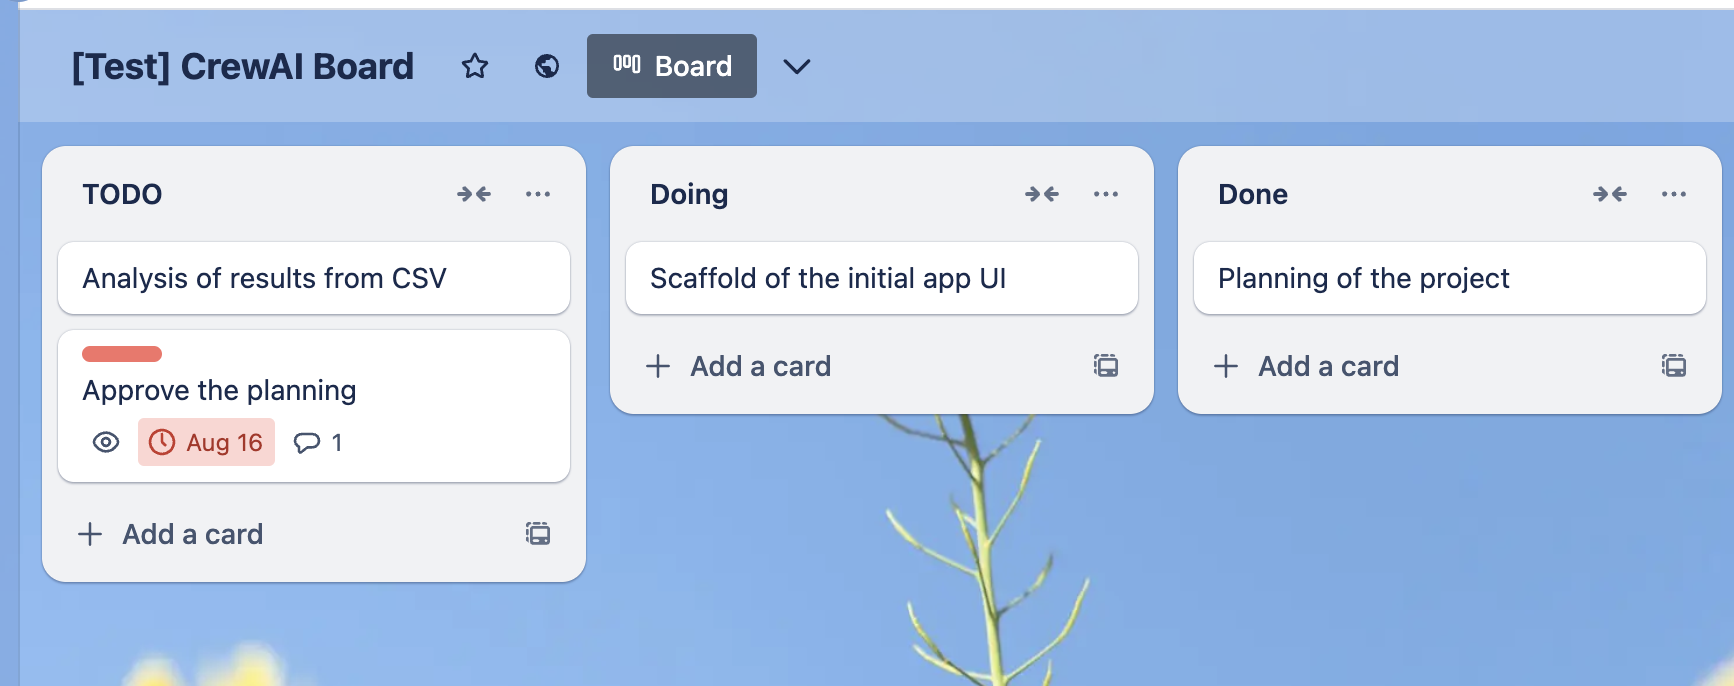

In [5]:
# Display the Trello screenshot
from IPython.display import Image, display

# Load and display the image
trello_image = Image(filename='trello.png')
display(trello_image)

## Create Crew, Agents and Tasks

In [6]:
# Creating Agents
data_collection_agent = Agent(
  config=agents_config['data_collection_agent'],
  tools=[BoardDataFetcherTool(), CardDataFetcherTool()]
)

analysis_agent = Agent(
  config=agents_config['analysis_agent']
)

# Creating Tasks
data_collection = Task(
  config=tasks_config['data_collection'],
  agent=data_collection_agent
)

data_analysis = Task(
  config=tasks_config['data_analysis'],
  agent=analysis_agent
)

report_generation = Task(
  config=tasks_config['report_generation'],
  agent=analysis_agent,
)

# Creating Crew
crew = Crew(
  agents=[
    data_collection_agent,
    analysis_agent
  ],
  tasks=[
    data_collection,
    data_analysis,
    report_generation
  ],
  verbose=True
)

## Kickoff Crew

In [7]:
# Kick off the crew and execute the process
result = crew.kickoff()

# Agent: Data Collection Specialist
## Task: Create an initial understanding of the project, its main features and the team working on it. Use the Trello Data Fetcher tool to gather data from the Trello board.



# Agent: Data Collection Specialist
## Thought: I need to gather all relevant data from the Trello board to create a full report on the project, its main features, and the team working on it.
## Using tool: Trello Board Data Fetcher
## Tool Input: 
"{}"
## Tool Output: 
[{'id': '66c3bfed69b473b8fe9d922e', 'name': 'Analysis of results from CSV', 'idList': '66c308f676b057fdfbd5fdb3', 'due': None, 'dateLastActivity': '2024-08-19T21:58:05.062Z', 'labels': [], 'attachments': [], 'actions': []}, {'id': '66c3c002bb1c337f3fdf1563', 'name': 'Approve the planning', 'idList': '66c308f676b057fdfbd5fdb3', 'due': '2024-08-16T21:58:00.000Z', 'dateLastActivity': '2024-08-19T21:58:57.697Z', 'labels': [{'id': '66c305ea10ea602ee6e03d47', 'idBoard': '66c305eacab50fcd7f19c0aa', 'idOrganization': '



# Agent: Data Collection Specialist
## Final Answer: 
### Project Report

**Project Overview:**
This project is managed on Trello and involves various tasks aimed at developing and planning a software application.

**Main Features:**

1. **Analysis of Results from CSV**
   - **ID:** 66c3bfed69b473b8fe9d922e
   - **URL:** [View Card](https://trello.com/c/GjHNaKq3/2-analysis-of-results-from-csv)
   - **Description:** Not provided.
   - **Date Last Activity:** August 19, 2024
   - **Comments:** 0

2. **Approve the Planning**
   - **ID:** 66c3c002bb1c337f3fdf1563
   - **URL:** [View Card](https://trello.com/c/K3abXIMm/5-approve-the-planning)
   - **Due Date:** August 16, 2024
   - **Label:** Urgent
   - **Comments:** 1
   - **Last Comment by:** Joao Moura
     - **Comment:** "This was harder than expected."
   - **Date Last Activity:** August 19, 2024

3. **Scaffold of the Initial App UI**
   - **ID:** 66c3bff4a25b398ef1b6de78
   - **URL:** [View Card](https://trello.com/c/Qv9IHf78/3-sca

## Usage Metrics and Costs

Let’s see how much it would cost each time if this crew runs at scale.

In [8]:
import pandas as pd

costs = 0.150 * (crew.usage_metrics.prompt_tokens + crew.usage_metrics.completion_tokens) / 1_000_000
print(f"Total costs: ${costs:.4f}")

# Convert UsageMetrics instance to a DataFrame
df_usage_metrics = pd.DataFrame([crew.usage_metrics.dict()])
df_usage_metrics

Total costs: $0.0036


,total_tokens,prompt_tokens,completion_tokens,successful_requests
0,24106,19747,4359,12


## Report

In [9]:
from IPython.display import Markdown

markdown  = result.raw
Markdown(markdown)

# Sprint Report

## Sprint Overview
The current sprint period showcases critical phases in the software application development project, as tracked on Trello. The focus remains on task completion, team engagement, and addressing blockers that may inhibit project timelines.

## Task Summary
- **Total Tasks:** 4
- **Completed Tasks:** 0
- **In Progress:** 0
- **Blocked Tasks:** 4

### Task Details:
1. **Task:** Approve the Planning 
   - **ID:** 66c3c002bb1c337f3fdf1563 
   - **Due Date:** August 16, 2024 
   - **Status:** Blocked 
   - **Comments:** "This was harder than expected" - Joao Moura. 

2. **Task:** Analysis of Results from CSV 
   - **ID:** 66c3bfed69b473b8fe9d922e 
   - **Due Date:** Not Specified 
   - **Status:** Blocked 
   - **Comments:** No comments, indicating stagnation.

3. **Task:** Scaffold of the Initial App UI 
   - **ID:** 66c3bff4a25b398ef1b6de78 
   - **Due Date:** Not Specified 
   - **Status:** Blocked 
   - **Comments:** No updates provided.

4. **Task:** Planning of the Project 
   - **ID:** 66c3bffdb06faa1e69216c6f 
   - **Due Date:** Not Specified 
   - **Status:** Blocked 
   - **Comments:** No updates or comments.

## Identified Issues and Blockers
- **Approve the Planning (ID: 66c3c002bb1c337f3fdf1563):** The critical task remains unapproved, which is inhibiting the progress of all subsequent activities. The feedback indicates unforeseen challenges that must be addressed promptly.
- **Lack of Communication:** The absence of comments and activity on crucial tasks like "Analysis of Results from CSV," "Scaffold of the Initial App UI," and "Planning of the Project" suggests a significant lack of engagement from the team, which could lead to misalignment and further delays.

## Progress and Delays
Due to all tasks being in a blocked status, there are significant delays recorded. The project is at risk as no progress has been made in nearly all aspects, heightening the urgency for action to reinvigorate team participation and clear existing blockers.

## Team Performance Overview
Team performance has been lacking, as demonstrated by the stagnation of tasks and lack of communication. The engagement seems insufficient, as indicated by the absence of comments and updates. This lack of involvement may stem from a lack of direction or clarity on the project’s progress and requirements.

## Action Items and Recommendations
1. **Immediate Meeting:** Schedule a meeting with relevant stakeholders to discuss the blockers associated with "Approve the Planning." Ensuring its approval should be a priority.
  
2. **Encourage Team Collaboration:** Reinforce the necessity for team members to actively update their progress and communicate challenges. Implement regular check-ins to facilitate this.
  
3. **Task Re-Evaluation:** Assess each blocked task for opportunities to clarify expectations, redefine responsibilities, and set new, achievable deadlines where appropriate.
  
4. **Monitor Engagement:** Introduce engagement metrics to track active participation in task management on Trello, ensuring everyone is contributing to the project goals.

## Conclusion
The analysis of the current sprint indicates that the project is facing significant complications due to identified blockers. Swift action is necessary to resolve these issues and foster a more collaborative environment that will drive the project toward its successful completion. Immediate focus on communication and clarity will be essential for overcoming current obstacles.